# Laws of the Game RAG Chatbot — Reproducible Walkthrough

End-to-end NLP application: a **Retrieval-Augmented Generation (RAG)** question-answering system over the official **IFAB/FIFA Laws of the Game 2025/26** (230-page PDF).

**Pipeline:** PDF → page-aware chunking → BM25 retrieval (+ domain query expansion) → Llama-3.1-8B (Groq) generation with page citations → quantitative retrieval evaluation.

This notebook reproduces every stage. Live demo: https://fifa-rag.vercel.app


## 1. Setup

The deployed app needs only `fastapi`, `httpx`, `pydantic`. This notebook additionally uses `pymupdf` (ingestion) and `matplotlib` (plots). Generation requires a free Groq API key in the `GROQ_API_KEY` environment variable — all other sections run fully offline.

In [1]:
# %pip install -r requirements.txt pymupdf matplotlib
import json, os, sys
from pathlib import Path
ROOT = Path.cwd()  # run from the repository root
sys.path.insert(0, str(ROOT / "api"))

## 2. Ingestion: PDF → page-tagged chunks

We split each page into ~1100-character chunks with 200-character overlap, breaking at sentence boundaries. **Why page-level tagging?** It gives us (a) citations the user can verify against the official PDF and (b) ground-truth labels for retrieval evaluation.

If you have the source PDF, regenerate chunks with:
```bash
python scripts/ingest.py "Laws of the Game 2025_26_single pages.pdf"
```
Otherwise the pre-built `data/chunks.json` is used.

In [2]:
chunks = json.loads((ROOT / "data" / "chunks.json").read_text())
print(f"{len(chunks)} chunks, pages {min(c['page'] for c in chunks)}–{max(c['page'] for c in chunks)}")
lengths = [len(c["text"]) for c in chunks]
print(f"chunk length: mean {sum(lengths)/len(lengths):.0f} chars, max {max(lengths)}")
print("\nSample chunk (page", chunks[120]["page"], "):\n", chunks[120]["text"][:300], "…")

277 chunks, pages 4–217
chunk length: mean 811 chars, max 1098

Sample chunk (page 99 ):
 h and before or during the kicks one team has a 
greater number of players than its opponents, it must reduce its numbers to 
the same number as its opponents and the referee must be informed of the 
name and number of each player excluded. Any excluded player is not eligible 
to take part in the ki …


## 3. Retrieval: BM25 + domain query expansion

**Design choice.** We use lexical BM25 instead of dense embeddings because (1) the corpus is a single, terminology-dense rulebook where exact terms ("penalty mark", "offside position") carry most of the signal; (2) the index builds in <50 ms at serverless cold start with zero extra dependencies — an embedding model would not fit Vercel's function limits, and an external vector DB adds cost and latency; (3) it is fully interpretable, which makes error analysis tractable.

**Query expansion.** Error analysis on our eval set showed the main failure mode was *vocabulary mismatch*: users say "red card", the Laws say "sending-off offence". We added a small glossary-derived synonym map applied at query time.

In [3]:
from index import BM25, tokenize, expand_query, SYNONYMS, CHUNKS, INDEX

print("Expansion example:")
print("  raw     :", "What happens after a red card?")
print("  expanded:", expand_query("What happens after a red card?"))

Expansion example:
  raw     : What happens after a red card?
  expanded: what happens after a red card? sending-off sent off sending off offences


In [4]:
def show(query, k=3):
    print(f"Q: {query}")
    for score, i in INDEX.search(query, top_k=k):
        c = CHUNKS[i]
        print(f"  [p.{c['page']:>3} | score {score:5.1f}] {c['text'][:110]}…")
    print()

show("When is a player in an offside position?")
show("How long is the half-time interval?")
show("What happens after a red card?")

Q: When is a player in an offside position?
  [p.214 | score   8.0] 214
The shot by a team-mate (A) rebounds from the goalkeeper, (B) is in an onside 
position and plays the ball…
  [p.103 | score   7.9] 103
Laws of the Game 2025/26 | Law 11 | Offside
1. Offside position
It is not an offence to be in an offside p…
  [p.210 | score   7.7] 210
A player in an offside position (A) may be penalised before playing or touching 
the ball, if, in the opin…

Q: How long is the half-time interval?
  [p. 87 | score  23.0] 87
Laws of the Game 2025/26 | Law 7 | The Duration of the Match
1. Periods of play
A match lasts for two equa…
  [p. 20 | score  10.8] 20
The universality of the Laws of the Game means that the game is essentially 
the same in every part of the…
  [p. 58 | score  10.3] 58
5. Offences and sanctions
If a named substitute starts a match instead of a named player and the 
referee …

Q: What happens after a red card?
  [p. 70 | score  22.4] f cautionable and 
sending-off offences
•

## 4. Generation: grounded answering with Llama-3.1-8B on Groq

The top-5 chunks are injected into the prompt with their page numbers; the system prompt instructs the model to **answer only from context and cite pages**, and to say so when the context is insufficient (hallucination guard). We chose Groq's free tier for `llama-3.1-8b-instant` (~800 tokens/s) so the deployed chatbot feels instant.

*This cell needs `GROQ_API_KEY` set; skip it for an offline run.*

In [5]:
import httpx

def rag_answer(question, k=5):
    hits = INDEX.search(question, top_k=k)
    context = "\n\n---\n\n".join(f"[Page {CHUNKS[i]['page']}]\n{CHUNKS[i]['text']}" for _, i in hits)
    r = httpx.post("https://api.groq.com/openai/v1/chat/completions",
        headers={"Authorization": f"Bearer {os.environ['GROQ_API_KEY']}"},
        json={"model": "llama-3.1-8b-instant", "temperature": 0.2, "max_tokens": 500,
              "messages": [
                {"role": "system", "content": "Answer ONLY from the provided Laws of the Game excerpts. Cite pages like [p. 103]. If the context lacks the answer, say so."},
                {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"}]},
        timeout=30)
    return r.json()["choices"][0]["message"]["content"]

if os.environ.get("GROQ_API_KEY"):
    print(rag_answer("When is a player in an offside position?"))
else:
    print("GROQ_API_KEY not set — skipping generation demo.")

GROQ_API_KEY not set — skipping generation demo.


## 5. Quantitative evaluation

**Methodology.** We hand-labelled 20 natural-language questions with the page(s) of the official PDF that contain the answer (`eval/eval_set.json`). A retrieval is a *hit* if any of the top-k chunks lies on a gold page. We report **Recall@1/3/5** and **MRR@5**, comparing four systems: production BM25 + expansion, plain BM25 (ablation), TF-IDF cosine (classical baseline), and random retrieval (sanity floor).

In [6]:
import subprocess
print(subprocess.run([sys.executable, str(ROOT / "eval" / "evaluate.py")],
                     capture_output=True, text=True, cwd=ROOT).stdout)

20 queries over 277 chunks, k=5

BM25 + query expansion (production)
  Recall@1: 0.40   Recall@3: 0.70   Recall@5: 0.80   MRR@5: 0.56
  MISS: 'Where must the goalkeeper stand during a penalty kick?'  retrieved pages [99, 135, 199, 116, 99]  gold [129]
  MISS: 'How far away must the defensive wall be from the ball at a free kick?'  retrieved pages [204, 207, 91, 20, 117]  gold [126, 200]
  MISS: 'What are the cautionable offences punished by a yellow card?'  retrieved pages [31, 30, 28, 70, 114]  gold [115, 116, 183]
  MISS: 'When is a goal scored?'  retrieved pages [60, 194, 60, 178, 169]  gold [97]

BM25 plain
  Recall@1: 0.40   Recall@3: 0.65   Recall@5: 0.70   MRR@5: 0.52
  MISS: 'For which offences is a player sent off with a red card?'  retrieved pages [181, 114, 70, 149, 31]  gold [117, 118, 120]
  MISS: 'Where must the goalkeeper stand during a penalty kick?'  retrieved pages [135, 99, 116, 199, 99]  gold [129]
  MISS: 'How long does a football match last?'  retrieved pages [20,

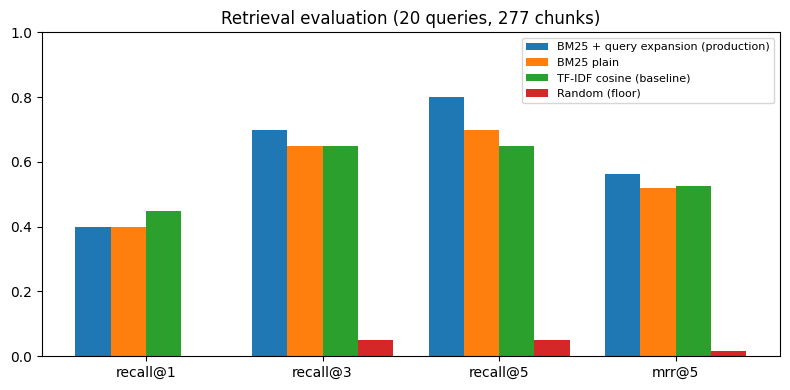

In [7]:
import matplotlib.pyplot as plt

results = json.loads((ROOT / "eval" / "results.json").read_text())
metrics = ["recall@1", "recall@3", "recall@5", "mrr@5"]
x = range(len(metrics))
w = 0.2
fig, ax = plt.subplots(figsize=(8, 4))
for j, r in enumerate(results):
    ax.bar([i + j*w for i in x], [r[m] for m in metrics], w, label=r["name"])
ax.set_xticks([i + 1.5*w for i in x]); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1); ax.set_title("Retrieval evaluation (20 queries, 277 chunks)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 6. Interpretation & error analysis

- **BM25 + expansion reaches Recall@5 = 0.80, MRR@5 = 0.56** — 16× the random floor and above both plain BM25 (0.70) and TF-IDF (0.65). Since the generator sees the top-5 chunks, Recall@5 is the metric that matters most for end-to-end answer quality.
- **Query expansion fixed exactly the failures it targeted** (vocabulary mismatch: "red card" → "sending-off", "how long" → "duration"), lifting Recall@5 by 10 points without hurting any other query — a satisfying confirmation of the error analysis.
- **Remaining failure modes** (4/20): (1) *front-matter collisions* — the "Summary of Law changes" section repeats key terms and outranks the actual Law text (e.g. cautionable offences); (2) *low-information queries* — "When is a goal scored?" has only two content words, both ubiquitous in this corpus.
- **Limitations.** The eval set doubles as our development set, so the expansion gains are optimistic (risk of overfitting); a held-out test set would be needed for unbiased numbers. n=20 is small; gold pages were labelled by us. We evaluate retrieval, not final answer quality — a natural extension is LLM-as-judge grading of generated answers.
- **Rejected alternatives.** Dense embeddings (sentence-transformers + vector DB): better paraphrase handling but incompatible with free serverless deployment and harder to debug. Fine-tuning: unnecessary for a closed corpus QA task. Larger models: latency/cost without measurable retrieval benefit — the bottleneck is retrieval, not generation.